In [26]:
# ============================================================
# CELL 1: Import & Load Session
# ============================================================
import numpy as np
import pickle
import random
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score,
                            confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load session
with open('session/session_preprocessing.pkl', 'rb') as f:
    sv = pickle.load(f)

le             = sv['le']
scaler         = sv['scaler']
num_classes    = sv['num_classes']
SEED           = sv['SEED']

X_train_scaled = sv['X_train_scaled']
X_val_scaled   = sv['X_val_scaled']
X_test_scaled  = sv['X_test_scaled']
y_train_oh     = sv['y_train_oh']
y_val_oh       = sv['y_val_oh']
y_test_oh      = sv['y_test_oh']
y_test         = sv['y_test']

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print("✅ Session loaded")
print(f"   Train : {X_train_scaled.shape}")
print(f"   Val   : {X_val_scaled.shape}")
print(f"   Test  : {X_test_scaled.shape}")
print(f"   SEED  : {SEED}")

✅ Session loaded
   Train : (1540, 7)
   Val   : (330, 7)
   Test  : (330, 7)
   SEED  : 42


In [27]:
# ============================================================
# CELL 2: Konfigurasi
# ============================================================

# Arsitektur
INPUT_DIM  = 7
HIDDEN_DIM = 32
OUTPUT_DIM = num_classes  # 22

# Training
EPOCHS     = 100
BATCH_SIZE = 32
LR         = 0.001

print("✅ Konfigurasi:")
print(f"   Arsitektur : {INPUT_DIM} → {HIDDEN_DIM} → {OUTPUT_DIM}")
print(f"   Epochs     : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR         : {LR}")

✅ Konfigurasi:
   Arsitektur : 7 → 32 → 22
   Epochs     : 100
   Batch size : 32
   LR         : 0.001


In [28]:
# ============================================================
# CELL 3: Bangun Model Baseline MLP
# Rujukan: BAB 3 hal 46-47, Tabel 3.9
#
# Arsitektur: Input(7) → Hidden(32, ReLU) → Output(22, Softmax)
# Satu hidden layer — sesederhana mungkin
# sebagai pure data-driven baseline
# ============================================================

def build_baseline():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(INPUT_DIM,)),
        tf.keras.layers.Dense(HIDDEN_DIM, activation='relu'),
        tf.keras.layers.Dense(OUTPUT_DIM, activation='softmax')
    ])
    return model

tf.random.set_seed(SEED)
model = build_baseline()
model.summary()

total_params = model.count_params()
print(f"\n✅ Total parameter: {total_params}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 982 (3.84 KB)

 Trainable params: 982 (3.84 KB)

 Non-trainable params: 0 (0.00 B)


✅ Total parameter: 982


In [29]:
# ============================================================
# CELL 4: Loss Function
# Rujukan: BAB 3 hal 50, formula L_data
#
# L_data = -1/N Σ Σ y_ic × log(ŷ_ic)
# ============================================================

def cross_entropy_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    return -tf.reduce_mean(
        tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1)
    )

# Test
X_dummy = tf.constant(X_train_scaled[:32], dtype=tf.float32)
y_dummy = tf.constant(y_train_oh[:32],     dtype=tf.float32)
y_pred  = model(X_dummy, training=False)
loss    = cross_entropy_loss(y_dummy, y_pred)

print(f"✅ Loss function siap")
print(f"   Loss awal (random): {loss.numpy():.4f}")
print(f"   Ekspektasi        : ~{np.log(OUTPUT_DIM):.4f} "
      f"(log {OUTPUT_DIM} kelas)")

✅ Loss function siap
   Loss awal (random): 3.2253
   Ekspektasi        : ~3.0910 (log 22 kelas)


In [30]:
# ============================================================
# CELL 5: Training Loop
# Rujukan: BAB 3 hal 47-57
#
# Tanpa early stopping — fixed 100 epochs
# Semua model menggunakan loop yang sama
# agar perbandingan adil
# ============================================================

def train_epoch(model, optimizer, X, y, batch_size, seed_offset):
    """Satu epoch training — return loss dan accuracy"""
    n   = X.shape[0]
    np.random.seed(SEED + seed_offset)
    idx = np.random.permutation(n)
    X   = X[idx]
    y   = y[idx]

    losses  = []
    correct = 0

    for i in range(0, n, batch_size):
        X_batch = tf.constant(X[i:i+batch_size], dtype=tf.float32)
        y_batch = tf.constant(y[i:i+batch_size], dtype=tf.float32)

        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            loss   = cross_entropy_loss(y_batch, y_pred)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(
            zip(grads, model.trainable_variables)
        )

        losses.append(loss.numpy())
        correct += np.sum(
            np.argmax(y_pred.numpy(), axis=1) ==
            np.argmax(y_batch.numpy(), axis=1)
        )

    return np.mean(losses), correct / n


def evaluate(model, X, y):
    """Evaluasi model — return loss dan accuracy"""
    X_tf   = tf.constant(X, dtype=tf.float32)
    y_tf   = tf.constant(y, dtype=tf.float32)
    y_pred = model(X_tf, training=False)
    loss   = cross_entropy_loss(y_tf, y_pred).numpy()
    acc    = np.mean(
        np.argmax(y_pred.numpy(), axis=1) ==
        np.argmax(y, axis=1)
    )
    return loss, acc


print("✅ Training loop siap")

✅ Training loop siap


In [31]:
# ============================================================
# CELL 6: Training Baseline
# ============================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

print("=== TRAINING BASELINE MLP ===")
print(f"   Arsitektur : {INPUT_DIM} → {HIDDEN_DIM} → {HIDDEN_DIM_2} → {OUTPUT_DIM}")
print(f"Epochs     : {EPOCHS}")
print(f"Batch size : {BATCH_SIZE}\n")

for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = train_epoch(
        model, optimizer,
        X_train_scaled, y_train_oh,
        BATCH_SIZE, seed_offset=epoch
    )

    # Validasi
    val_loss, val_acc = evaluate(
        model, X_val_scaled, y_val_oh
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"val_acc: {val_acc:.4f}")

print(f"\n✅ Training selesai")
print(f"   Best Val Acc  : {max(history['val_acc']):.4f} "
      f"(epoch {np.argmax(history['val_acc'])+1})")
print(f"   Final Val Acc : {history['val_acc'][-1]:.4f}")

=== TRAINING BASELINE MLP ===
   Arsitektur : 7 → 32 → 22 → 22
Epochs     : 100
Batch size : 32

Epoch  10/100 | train_loss: 0.7549 | val_loss: 0.7152 | train_acc: 0.8701 | val_acc: 0.8667
Epoch  20/100 | train_loss: 0.3127 | val_loss: 0.3110 | train_acc: 0.9435 | val_acc: 0.9545
Epoch  30/100 | train_loss: 0.1912 | val_loss: 0.1920 | train_acc: 0.9656 | val_acc: 0.9667
Epoch  40/100 | train_loss: 0.1369 | val_loss: 0.1383 | train_acc: 0.9727 | val_acc: 0.9697
Epoch  50/100 | train_loss: 0.1041 | val_loss: 0.1063 | train_acc: 0.9779 | val_acc: 0.9818
Epoch  60/100 | train_loss: 0.0854 | val_loss: 0.0866 | train_acc: 0.9831 | val_acc: 0.9818
Epoch  70/100 | train_loss: 0.0698 | val_loss: 0.0716 | train_acc: 0.9838 | val_acc: 0.9848
Epoch  80/100 | train_loss: 0.0600 | val_loss: 0.0610 | train_acc: 0.9883 | val_acc: 0.9909
Epoch  90/100 | train_loss: 0.0519 | val_loss: 0.0534 | train_acc: 0.9903 | val_acc: 0.9879
Epoch 100/100 | train_loss: 0.0460 | val_loss: 0.0481 | train_acc: 0.9896 |

In [32]:
# ============================================================
# CELL 7: Evaluasi Test Set
# Rujukan: BAB 3 hal 58-60
# ============================================================

X_test_tf = tf.constant(X_test_scaled, dtype=tf.float32)
y_pred    = model(X_test_tf, training=False).numpy()
y_true    = y_test
y_pred_l  = np.argmax(y_pred, axis=1)

acc  = accuracy_score(y_true, y_pred_l)
prec = precision_score(y_true, y_pred_l,
                       average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred_l,
                    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred_l,
                average='macro', zero_division=0)
cm   = confusion_matrix(y_true, y_pred_l)

print("=== EVALUASI TEST SET ===")
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

# Misklasifikasi
print(f"\n=== MISKLASIFIKASI ===")
total_errors = 0
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i][j] > 0:
            print(f"  {le.classes_[i]:15} → "
                  f"{le.classes_[j]:15} : {cm[i][j]} sampel")
            total_errors += cm[i][j]
print(f"\n  Total salah: {total_errors} dari "
      f"{len(y_true)} sampel test")

=== EVALUASI TEST SET ===
  Accuracy  : 0.9848 (98.48%)
  Precision : 0.9850 (98.50%)
  Recall    : 0.9848 (98.48%)
  F1-Score  : 0.9848 (98.48%)

=== MISKLASIFIKASI ===
  cotton          → maize           : 1 sampel
  jute            → rice            : 1 sampel
  maize           → cotton          : 1 sampel
  rice            → jute            : 2 sampel

  Total salah: 5 dari 330 sampel test


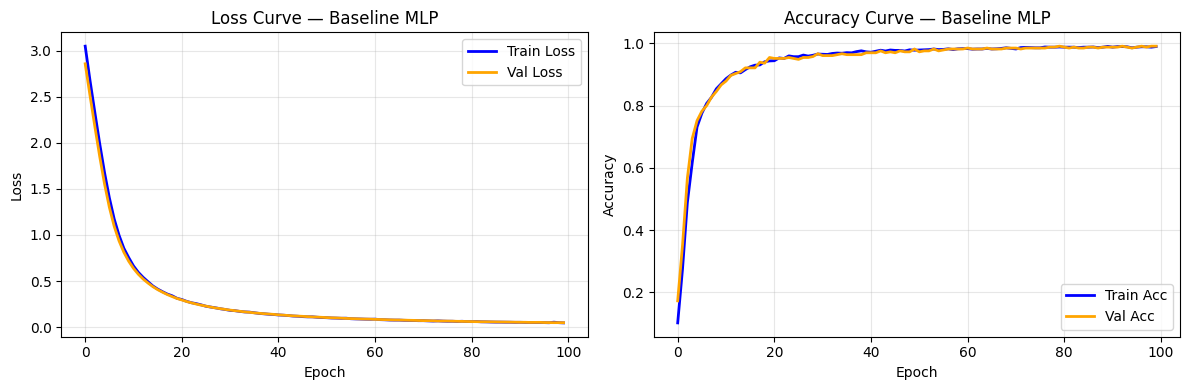

✅ Training curve disimpan


In [33]:
# ============================================================
# CELL 8: Plot Training Curve
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss',
             color='blue', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',
             color='orange', linewidth=2)
axes[0].set_title('Loss Curve — Baseline MLP')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Acc',
             color='blue', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val Acc',
             color='orange', linewidth=2)
axes[1].set_title('Accuracy Curve — Baseline MLP')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/01_baseline_training_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curve disimpan")

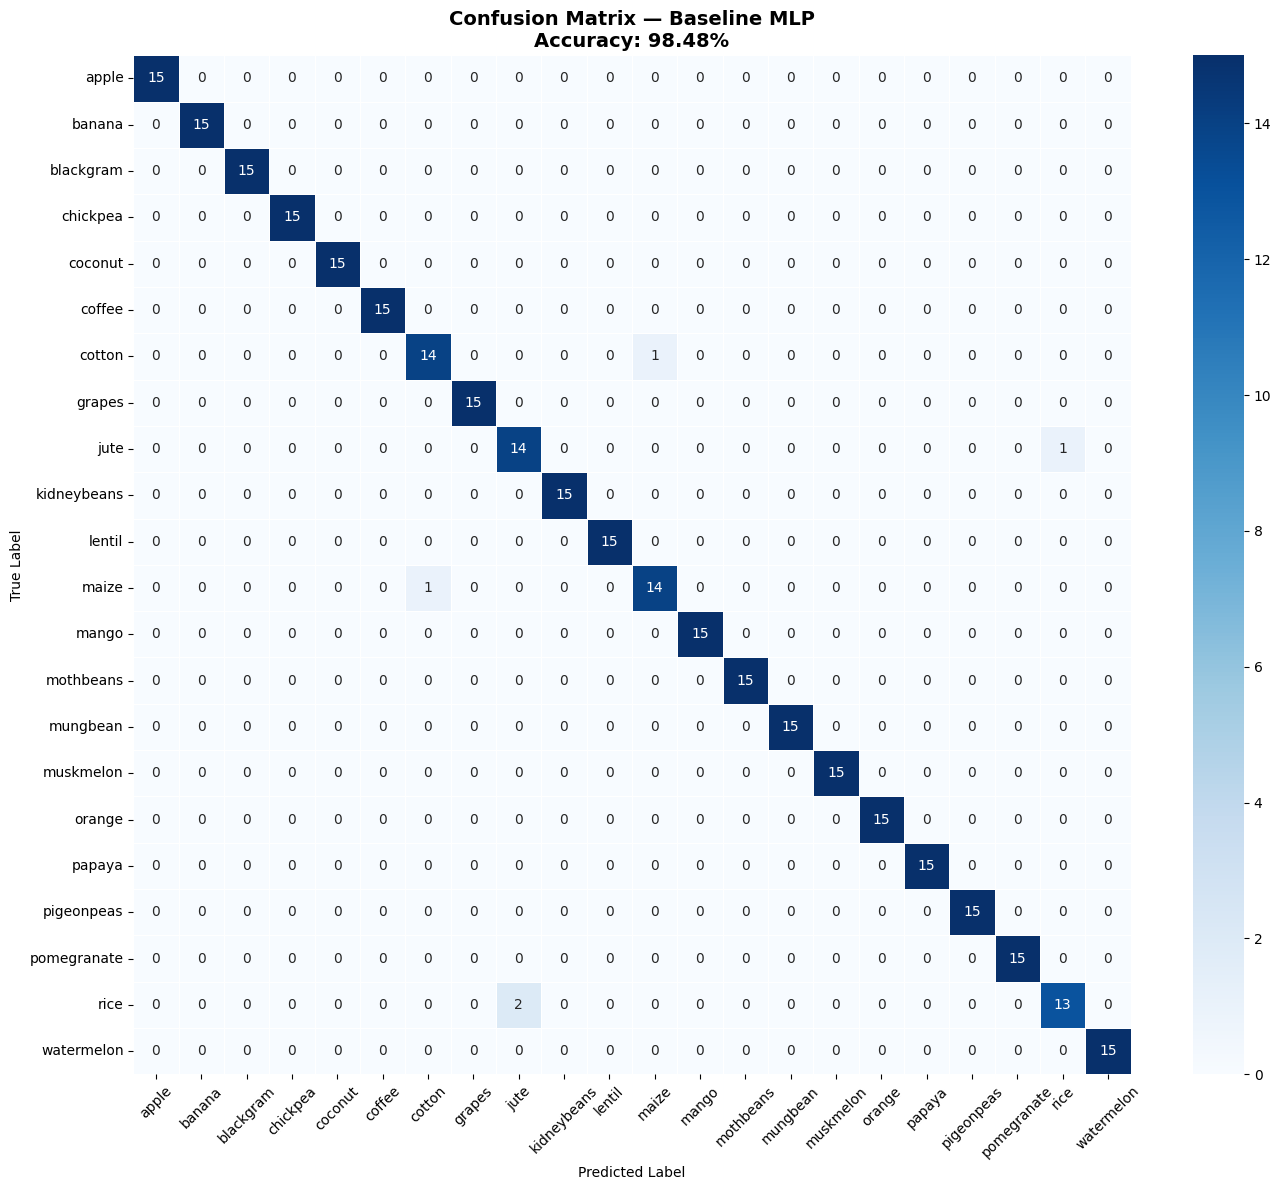

✅ Confusion matrix disimpan


In [34]:
# ============================================================
# CELL 9: Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_title(f'Confusion Matrix — Baseline MLP\n'
             f'Accuracy: {acc*100:.2f}%',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('results/01_baseline_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")

In [35]:
# ============================================================
# CELL 10: Simpan Model dan Hasil
# ============================================================

model.save('models/baseline_mlp.keras')

results_baseline = {
    'history'   : history,
    'metrics'   : {
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1_score' : f1,
    },
    'confusion_matrix': cm,
    'y_true'    : y_true,
    'y_pred'    : y_pred_l,
    'config'    : {
        'architecture': f'{INPUT_DIM}→{HIDDEN_DIM}→{OUTPUT_DIM}',
        'epochs'      : EPOCHS,
        'batch_size'  : BATCH_SIZE,
        'lr'          : LR,
    }
}

with open('session/results_baseline.pkl', 'wb') as f:
    pickle.dump(results_baseline, f)

print("✅ Model tersimpan  : models/baseline_mlp.keras")
print("✅ Hasil tersimpan  : session/results_baseline.pkl")
print(f"\nRingkasan:")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")

✅ Model tersimpan  : models/baseline_mlp.keras
✅ Hasil tersimpan  : session/results_baseline.pkl

Ringkasan:
  Accuracy  : 98.48%
  Precision : 98.50%
  Recall    : 98.48%
  F1-Score  : 98.48%
